# Arctic Atmosphere in a Warming Climate: ERA5 Sea-Ice Profiles

The Arctic is warming two to four times faster than the global mean — a phenomenon known as **Arctic amplification**.
Understanding *how* the vertical structure of temperature and humidity responds to declining sea ice is central to the
[(AC)³ project](https://ac3-tr.de) (*Arctic Amplification: Climate Relevant Atmospheric and Surface Processes, and Feedback Mechanisms*).

This notebook visualises decadal trends in atmospheric profiles binned by season and sea-ice cover fraction, derived
from ERA5 reanalysis data.  All data live in **xarray Datasets**, which makes the trend analysis — including the
`polyfit` call — a single line of code.


**Dataset** — `data/era5_sea_ice_to_libradtran.nc` (pre-processed by `era5_seasonal_sea_ice_profiles.ipynb`):

| Dimension | Description |
|---|---|
| `season` | DJF · MAM · JJA · SON |
| `valid_time` | Decade index (1979 – present) |
| `sea_ice_cover` | Fractional sea-ice concentration (0 → 1) |
| `pressure_level` | Atmospheric pressure in hPa |

The variables `t` (temperature, K) and `q` (specific humidity, kg kg⁻¹) are ensemble means within each bin.
A linear `polyfit` along `valid_time` converts the decadal time axis into a **trend** (K decade⁻¹ or g kg⁻¹ decade⁻¹).


In [2]:
# pip install cmcrameri

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cmocean
import cmcrameri.cm as cmc

# ── Global style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ds_out = xr.open_dataset('data/era5_sea_ice_to_libradtran.nc', chunks='auto')


/home/josh/micromamba/envs/mamba_josh/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [4]:
ds_out

<xarray.Dataset> Size: 100kB
Dimensions:         (season: 4, valid_time: 8, sea_ice_cover: 10,
                     pressure_level: 13)
Coordinates:
  * pressure_level  (pressure_level) int64 104B 50 100 150 200 ... 850 925 1000
  * season          (season) <U3 48B 'DJF' 'MAM' 'JJA' 'SON'
  * valid_time      (valid_time) datetime64[ns] 64B 1982-07-02T12:00:00 ... 2...
  * sea_ice_cover   (sea_ice_cover) float64 80B 0.05 0.15 0.25 ... 0.85 0.95
Data variables:
    t               (season, valid_time, sea_ice_cover, pressure_level) float64 33kB dask.array<chunksize=(4, 8, 10, 13), meta=np.ndarray>
    q               (season, valid_time, sea_ice_cover, pressure_level) float64 33kB dask.array<chunksize=(4, 8, 10, 13), meta=np.ndarray>
    theta           (season, valid_time, sea_ice_cover, pressure_level) float64 33kB dask.array<chunksize=(4, 8, 10, 13), meta=np.ndarray>

In [5]:
ds_out['theta'] = ds_out['t'] * (1000 / ds_out['pressure_level'])**0.286  # dry potential temperature (K)
ds_trend = ds_out - ds_out.mean(dim='valid_time')                          # anomaly relative to decadal mean


## Potential Temperature Trends (K decade⁻¹)

Dry potential temperature $\theta = T\,(p_0/p)^{0.286}$ removes the dry-adiabatic lapse rate, making
vertical structure easier to compare across seasons and ice fractions.

A first-order `polyfit` along the decade axis gives the **linear trend** at each (pressure, sea-ice) grid point.
Consistent warming in the lower troposphere over high ice-cover grid cells, particularly in winter (DJF),
is a characteristic signature of Arctic amplification.  The entire calculation — including the fit, unit conversion,
and faceted plot — relies on a handful of xarray operations.


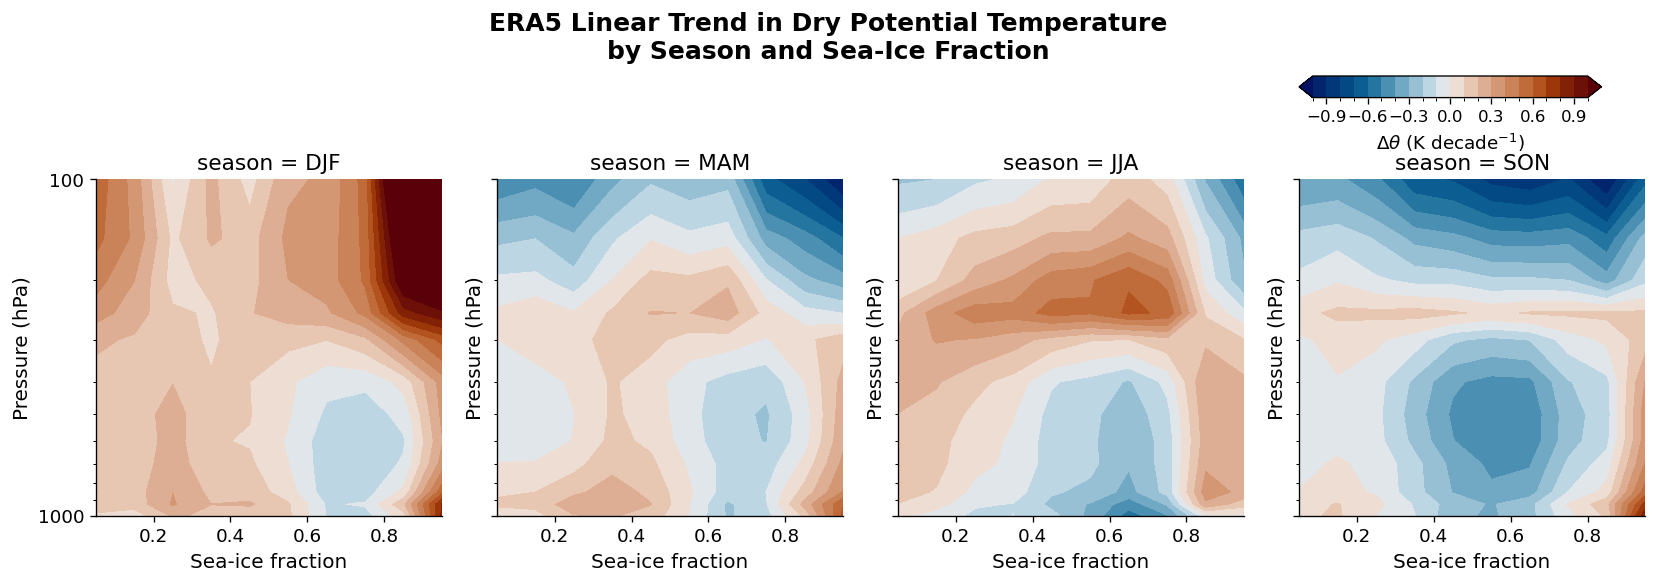

In [6]:
trend_theta = (
    ds_out.polyfit(dim='valid_time', deg=1)
    .isel(degree=0)
    .theta_polyfit_coefficients
    * (1e9 * 3600 * 24 * 365 * 10)   # convert ns⁻¹ → K decade⁻¹
)

levels = np.arange(-1.0, 1.05, 0.1)
fg = trend_theta.plot.contourf(
    y='pressure_level',
    ylim=(1000, 100),
    yscale='log',
    col='season',
    col_wrap=4,
    levels=levels,
    cmap=cmc.vik,          # perceptually uniform diverging (Crameri 2018)
    add_colorbar=False,
)

for ax in fg.axs.flat:
    ax.set_xlabel("Sea-ice fraction", fontsize=12)
    ax.set_ylabel("Pressure (hPa)", fontsize=12)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(labelsize=11)

fg.fig.suptitle(
    "ERA5 Linear Trend in Dry Potential Temperature\nby Season and Sea-Ice Fraction",
    y=1.08, fontsize=15, fontweight="bold",
)
fg.fig.set_size_inches(14, 4.5)
plt.tight_layout()

# ── Colorbar: upper-right corner, above the panel row ──────────────────────
# Grab the mappable from the first filled-contour artist in the FacetGrid
mappable = fg.axs.flat[0].collections[0]
cbar_ax = fg.fig.add_axes([0.78, 0.92, 0.18, 0.04])   # [left, bottom, width, height]
cb = fg.fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
cb.set_label(r"$\Delta\theta$ (K decade$^{-1}$)", fontsize=11)
cb.ax.tick_params(labelsize=10)

plt.show()


### Winter Close-Up: DJF Lower Troposphere

Arctic amplification is strongest in autumn and winter, when sea-ice retreat exposes the dark ocean to
long-wave emission and turbulent heat fluxes.  The panel below zooms into the DJF lower troposphere
(surface – 500 hPa) across the full sea-ice fraction range, resolving the near-surface inversion signal.

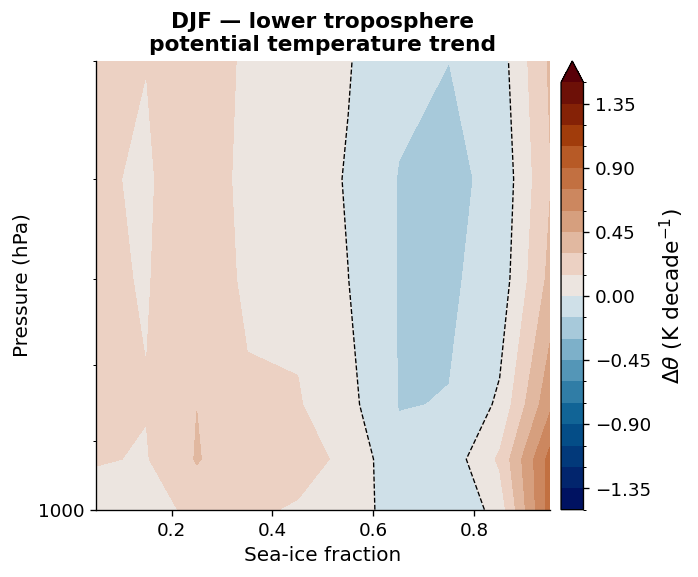

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

djf_trend = trend_theta.sel(season="DJF")

cf = djf_trend.plot.contourf(
    y="pressure_level",
    ylim=(1000, 500),
    yscale="log",
    levels=np.arange(-1.5, 1.55, 0.15),
    cmap=cmc.vik,
    ax=ax,
    add_colorbar=True,
    cbar_kwargs={"label": r"$\Delta\theta$ (K decade$^{-1}$)", "pad": 0.02},
)

# zero-trend contour for reference
djf_trend.plot.contour(
    y="pressure_level",
    ylim=(1000, 500),
    yscale="log",
    levels=[0],
    colors=["k"],
    linewidths=0.8,
    linestyles="--",
    ax=ax,
    add_colorbar=False,
)

ax.set_title("DJF — lower troposphere\npotential temperature trend", fontsize=13, fontweight="bold")
ax.set_xlabel("Sea-ice fraction", fontsize=12)
ax.set_ylabel("Pressure (hPa)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()


## Specific Humidity Trends (g kg⁻¹ decade⁻¹)

A warmer Arctic atmosphere holds more water vapour (Clausius–Clapeyron relation).
Moistening of the Arctic lower troposphere amplifies the greenhouse effect and feeds back
into further warming — making the humidity trend a key diagnostic for (AC)³ simulations
performed with pyRadtran.


/tmp/ipykernel_15137/479977737.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


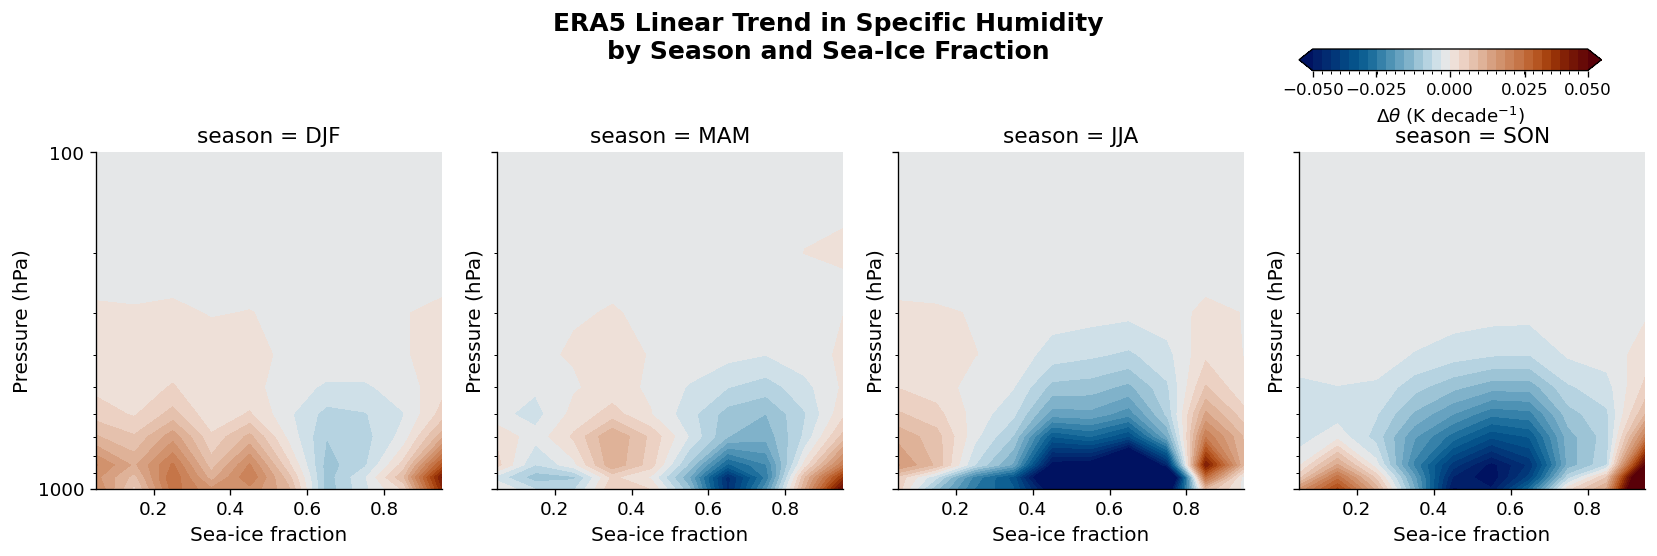

In [8]:
trend_q = (
    ds_out.polyfit(dim="valid_time", deg=1)
    .isel(degree=0)
    .q_polyfit_coefficients
    * (1e9 * 3600 * 24 * 365 * 10)   # ns⁻¹ → decade⁻¹
    * 1000                             # kg kg⁻¹ → g kg⁻¹
)

# symmetric levels centred on zero — changes in sign are clearly visible
vmax = float(np.abs(trend_q).quantile(0.97))
levels_q = np.linspace(-vmax, vmax, 31)

fg = trend_q.plot.contourf(
    y="pressure_level",
    ylim=(1000, 100),
    yscale="log",
    col="season",
    col_wrap=4,
    levels=levels_q,
    cmap=cmc.vik,
    add_colorbar=False,
    cbar_kwargs={
        "label": r"$\Delta q$ (g kg$^{-1}$ decade$^{-1}$)",
        "shrink": 0.8,
        "pad": 0.02,
    },
)

for ax in fg.axs.flat:
    ax.set_xlabel("Sea-ice fraction", fontsize=12)
    ax.set_ylabel("Pressure (hPa)", fontsize=12)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(labelsize=11)

fg.fig.suptitle(
    "ERA5 Linear Trend in Specific Humidity\nby Season and Sea-Ice Fraction",
    y=1.03, fontsize=15, fontweight="bold",
)
# ── Colorbar: upper-right corner, above the panel row ──────────────────────
# Grab the mappable from the first filled-contour artist in the FacetGrid
mappable = fg.axs.flat[0].collections[0]
cbar_ax = fg.fig.add_axes([0.78, 0.92, 0.18, 0.04])   # [left, bottom, width, height]
cb = fg.fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
cb.set_label(r"$\Delta\theta$ (K decade$^{-1}$)", fontsize=11)
cb.ax.tick_params(labelsize=10)
cb.ax.set_xticks([-0.05, -0.025, 0.00, 0.025, 0.05])


fg.fig.set_size_inches(14, 4.5)
plt.tight_layout()
plt.show()


## Absolute Temperature Profiles by Decade

While trends reveal *how fast* the Arctic is changing, the absolute temperature structure determines
which radiative transfer regime applies in pyRadtran simulations.  Each panel below shows a single
decade for the DJF season, binned by sea-ice fraction.

/tmp/ipykernel_15137/3686798213.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


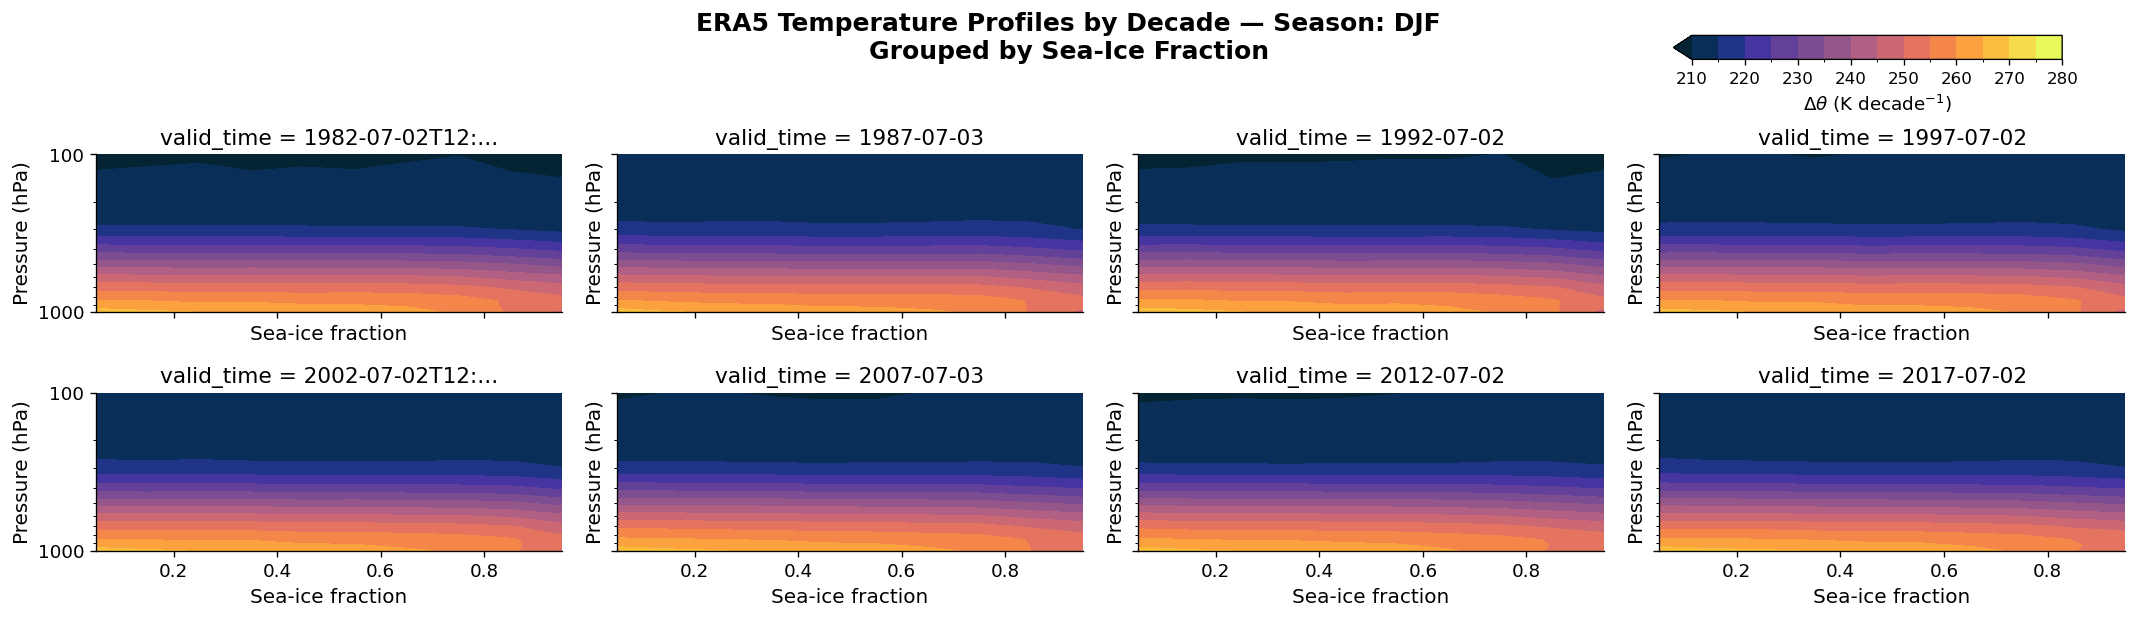

In [14]:
fg = ds_out.t.isel(season=0).plot.contourf(
    levels=np.arange(210, 281, 5),
    cmap=cmocean.cm.thermal,
    col="valid_time",
    col_wrap=4,
    yscale="log",
    y="pressure_level",
    ylim=(1000, 100),
    add_colorbar=False,
)

for ax in fg.axs.flat:
    ax.set_xlabel("Sea-ice fraction", fontsize=12)
    ax.set_ylabel("Pressure (hPa)", fontsize=12)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(labelsize=11)

season_name = str(ds_out.season.values[0])
fg.fig.suptitle(
    f"ERA5 Temperature Profiles by Decade — Season: {season_name}\nGrouped by Sea-Ice Fraction",
    y=1.03, fontsize=15, fontweight="bold",
)
mappable = fg.axs.flat[0].collections[0]
cbar_ax = fg.fig.add_axes([0.78, 0.95, 0.18, 0.04])   # [left, bottom, width, height]
cb = fg.fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
cb.set_label(r"$\Delta\theta$ (K decade$^{-1}$)", fontsize=11)
cb.ax.tick_params(labelsize=10)
#cb.ax.set_xticks([-0.05, -0.025, 0.00, 0.025, 0.05])




fg.fig.set_size_inches(18, 5)
plt.tight_layout()
plt.show()


## Decadal Snapshots: Temperature and Humidity Anomalies

The panels below show how the full atmospheric profile evolves decade by decade for a fixed season,
grouped by sea-ice fraction.  Plotting both the **absolute temperature** and the **anomaly relative
to the decadal mean** side-by-side highlights the signal-to-noise ratio of the Arctic warming signal.

Because both variables are stored in a single xarray `Dataset`, switching between absolute values
and anomalies is a one-line subtraction — the kind of operation that makes xarray indispensable for
climate data analysis.

/tmp/ipykernel_15137/4107186629.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


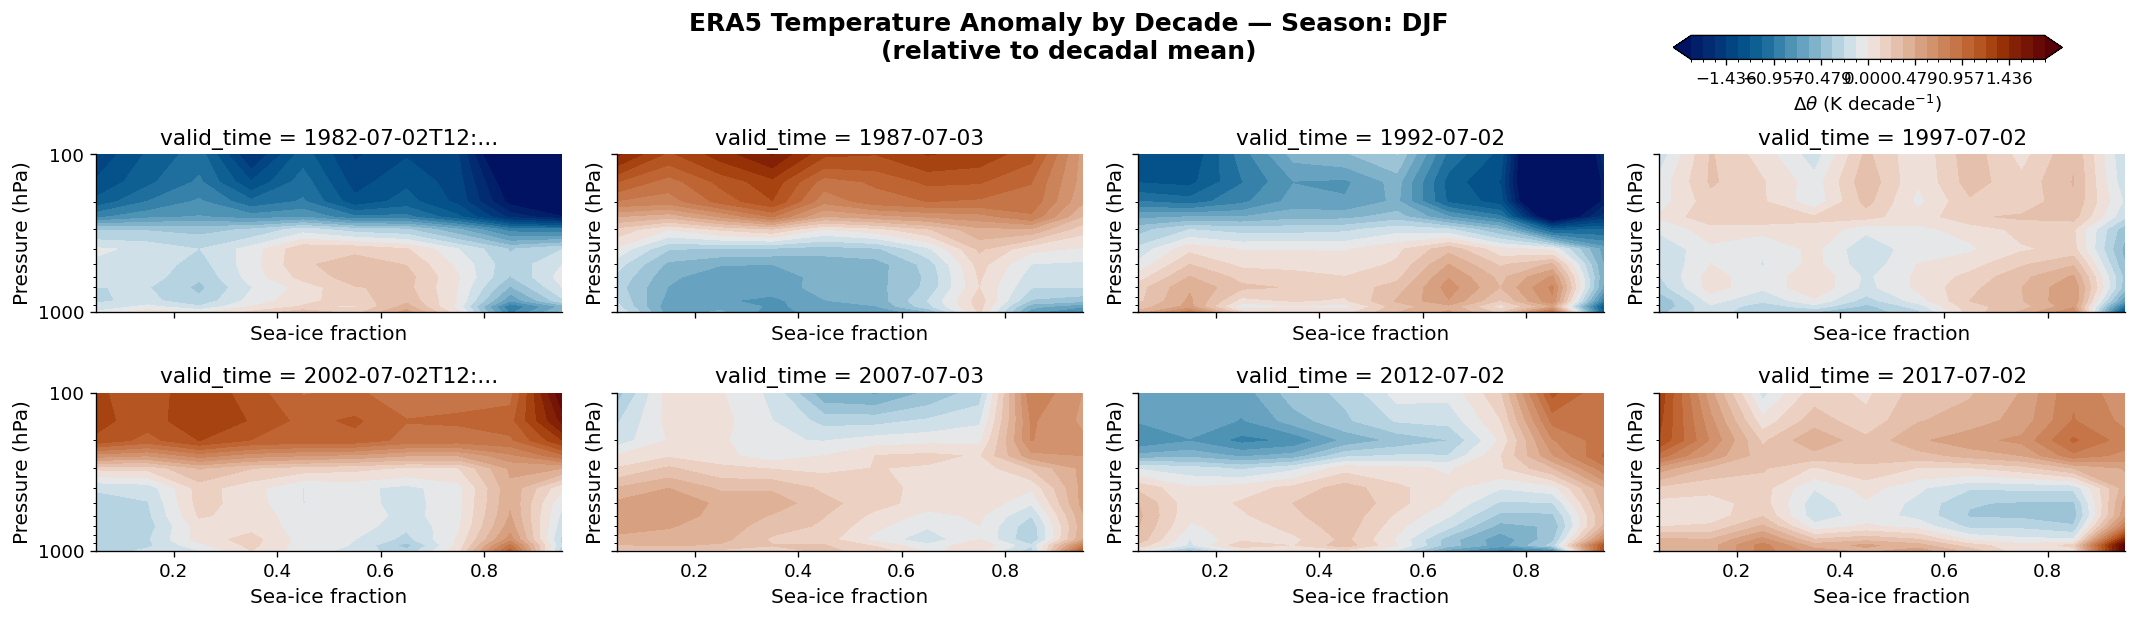

/tmp/ipykernel_15137/4107186629.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


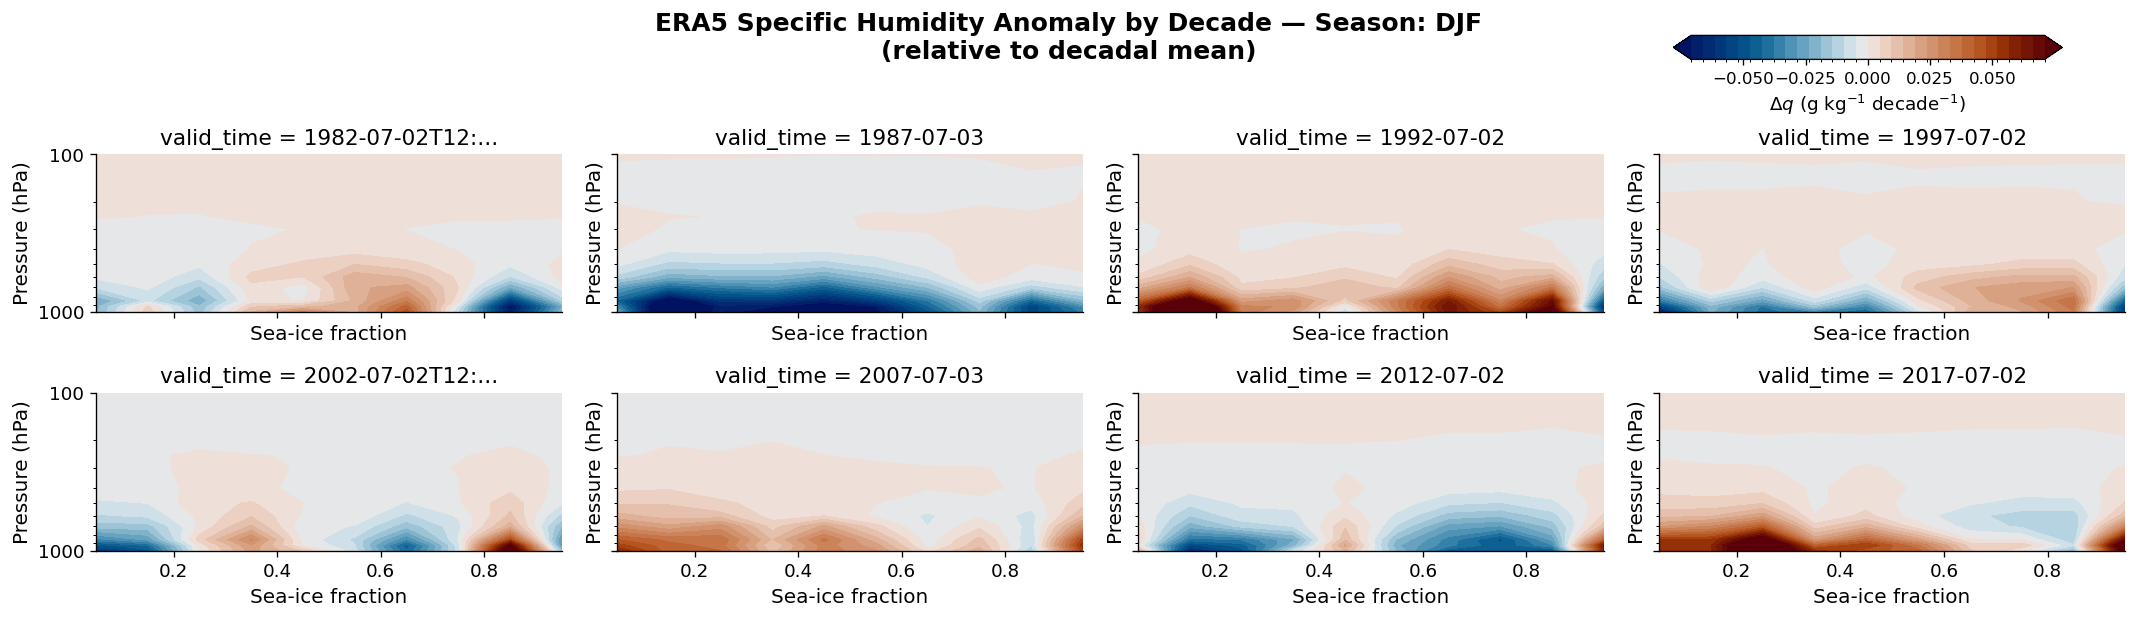

In [21]:
season_idx = 0  # DJF
season_name = str(ds_out.season.values[season_idx])

# ── Temperature anomaly ──────────────────────────────────────────────────────
max_t = float(np.abs(ds_trend.t.isel(season=season_idx)).quantile(0.98))
levels_t = np.linspace(-max_t, max_t, 31)

fg_t = ds_trend.t.isel(season=season_idx).plot.contourf(
    col="valid_time",
    col_wrap=4,
    yscale="log",
    y="pressure_level",
    ylim=(1000, 100),
    levels=levels_t,
    cmap=cmc.vik,
    add_colorbar=False
)

for ax in fg_t.axs.flat:
    ax.set_xlabel("Sea-ice fraction", fontsize=12)
    ax.set_ylabel("Pressure (hPa)", fontsize=12)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(labelsize=11)

fg_t.fig.suptitle(
    f"ERA5 Temperature Anomaly by Decade — Season: {season_name}\n(relative to decadal mean)",
    y=1.03, fontsize=15, fontweight="bold",
)
mappable = fg_t.axs.flat[0].collections[0]
cbar_ax = fg_t.fig.add_axes([0.78, 0.95, 0.18, 0.04])   # [left, bottom, width, height]
cb = fg_t.fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
cb.set_label(r"$\Delta\theta$ (K decade$^{-1}$)", fontsize=11)
cb.ax.tick_params(labelsize=10)
fg_t.fig.set_size_inches(18, 5)
plt.tight_layout()
plt.show()

# ── Specific humidity anomaly ────────────────────────────────────────────────
max_q = float(np.abs(ds_trend.q.isel(season=season_idx)).quantile(0.98)) * 1000  # g/kg

fg_q = (ds_trend.q.isel(season=season_idx) * 1000).plot.contourf(
    col="valid_time",
    col_wrap=4,
    yscale="log",
    y="pressure_level",
    ylim=(1000, 100),
    levels=np.linspace(-max_q, max_q, 31),
    cmap=cmc.vik,
    add_colorbar=False
)

for ax in fg_q.axs.flat:
    ax.set_xlabel("Sea-ice fraction", fontsize=12)
    ax.set_ylabel("Pressure (hPa)", fontsize=12)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(labelsize=11)

fg_q.fig.suptitle(
    f"ERA5 Specific Humidity Anomaly by Decade — Season: {season_name}\n(relative to decadal mean)",
    y=1.03, fontsize=15, fontweight="bold",
)
mappable = fg_q.axs.flat[0].collections[0]
cbar_ax = fg_q.fig.add_axes([0.78, 0.95, 0.18, 0.04])   # [left, bottom, width, height]
cb = fg_q.fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
cb.set_label(r"$\Delta q$ (g kg$^{-1}$ decade$^{-1}$)", fontsize=11)
cb.ax.tick_params(labelsize=10)
cb.ax.set_xticks([-0.05, -0.025, 0.00, 0.025, 0.05])
fg_q.fig.set_size_inches(18, 5)
plt.tight_layout()
plt.show()
